# HW4 — Sequence Modeling: Financial Forecasting
**CS515 Deep Learning | Sabanci University**

This notebook:
1. Clones the repository and installs missing dependencies with uv
2. Runs Part b (exact return), Part c (rolling return), and Part d (turning point) experiments on the GPU
3. Displays results and prepares them for download

> **Important:** Runtime → Change runtime type → select **T4 GPU**.

## 0. GPU Kontrolü

In [4]:
import torch

print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
    print(f'VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: no GPU detected — select T4 GPU from the Runtime menu!')


CUDA available : True
GPU            : Tesla T4
VRAM           : 15.6 GB


## 1. Repository Setup

In [5]:
import os

REPO_URL = 'https://github.com/caltinuzengi/cs515-deep-learning.git'
REPO_DIR = 'cs515-deep-learning'

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
else:
    print('Repo already exists, pulling latest...')
    !git -C {REPO_DIR} pull

os.chdir(REPO_DIR)
print(f'Directory: {os.getcwd()}')


Cloning into 'cs515-deep-learning'...
remote: Enumerating objects: 595, done.
remote: Counting objects: 100% (217/217), done.
remote: Compressing objects: 100% (165/165), done.
remote: Total 595 (delta 68), reused 182 (delta 42), pack-reused 378 (from 3)
Receiving objects: 100% (595/595), 518.41 MiB | 19.76 MiB/s, done.
Resolving deltas: 100% (137/137), done.
Updating files: 100% (344/344), done.
Directory: /content/cs515-deep-learning


## 2. Dependency Setup (uv)

Colab's CUDA-enabled torch is preserved; only missing packages are added.

In [6]:
# Install uv (with PyPI)
!pip install uv -q

# Add missing packages to the system Python (does not change Colab's torch/CUDA)
!uv pip install --system yfinance scikit-learn ptflops -q

# Check versions of the installed packages
import yfinance, sklearn
print(f'yfinance   : {yfinance.__version__}')
print(f'scikit-learn: {sklearn.__version__}')
print(f'torch      : {torch.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 93.2 MB/s eta 0:00:00:00:0100:01
yfinance   : 0.2.66
scikit-learn: 1.6.1
torch      : 2.11.0+cu128


## 3. Data Download and Validation

In [7]:
!python hw4/data_pipeline.py

=== Downloading data ===
  AAPL: 1508 rows → data/stocks/raw/AAPL.csv
  MSFT: 1508 rows → data/stocks/raw/MSFT.csv
  GOOGL: 1508 rows → data/stocks/raw/GOOGL.csv

=== ReturnDataset (exact) ===
  train: 3399 samples
  val  : 318 samples
  test : 735 samples

=== ReturnDataset (rolling) ===
  train: 3399 samples
  val  : 318 samples
  test : 735 samples

=== TurningPointDataset ===
  train: 3399 samples  |  class 1: 113 (3.3%)  class 0: 3286 (96.7%)
  val  : 318 samples  |  class 1: 7 (2.2%)  class 0: 311 (97.8%)
  test : 735 samples  |  class 1: 32 (4.4%)  class 0: 703 (95.6%)

=== Batch shapes ===
  X:         (64, 20, 4)
  y_exact:   (64, 5)
  y_rolling: (64, 5)
  y_binary:  (64, 1)


## 4. Part b — Exact Return Forecasting (StockLSTM & StockGRU)

In [8]:
!python hw4/experiment_b.py --retrain

device: cuda
loading data...

[StockLSTM] training...
Epoch   1/100 * | train=0.001622 | val=0.000700 | best=1
Epoch   2/100 * | train=0.001165 | val=0.000688 | best=2
Epoch   3/100 * | train=0.001120 | val=0.000666 | best=3
Epoch   4/100 * | train=0.001111 | val=0.000630 | best=4
Epoch   5/100   | train=0.001087 | val=0.000644 | best=4
Epoch   6/100   | train=0.001079 | val=0.000649 | best=4
Epoch   7/100   | train=0.001071 | val=0.000666 | best=4
Epoch   8/100   | train=0.001069 | val=0.000703 | best=4
Epoch   9/100 * | train=0.001072 | val=0.000624 | best=9
Epoch  10/100   | train=0.001064 | val=0.000633 | best=9
Epoch  11/100   | train=0.001055 | val=0.000687 | best=9
Epoch  12/100   | train=0.001053 | val=0.000684 | best=9
Epoch  13/100   | train=0.001054 | val=0.000648 | best=9
Epoch  14/100   | train=0.001049 | val=0.000681 | best=9
Epoch  15/100   | train=0.001050 | val=0.000665 | best=9
Epoch  16/100   | train=0.001047 | val=0.000662 | best=9
Epoch  17/100   | train=0.001044 |

## 5. Part c — Rolling Average Return Forecasting

In [9]:
!python hw4/experiment_c.py --retrain

device: cuda
loading data...

[StockLSTM] training...
Epoch   1/100 * | train=0.001028 | val=0.000298 | best=1
Epoch   2/100   | train=0.000566 | val=0.000316 | best=1
Epoch   3/100 * | train=0.000527 | val=0.000281 | best=3
Epoch   4/100 * | train=0.000507 | val=0.000279 | best=4
Epoch   5/100   | train=0.000490 | val=0.000283 | best=4
Epoch   6/100   | train=0.000488 | val=0.000288 | best=4
Epoch   7/100   | train=0.000478 | val=0.000289 | best=4
Epoch   8/100   | train=0.000473 | val=0.000318 | best=4
Epoch   9/100 * | train=0.000476 | val=0.000272 | best=9
Epoch  10/100   | train=0.000467 | val=0.000274 | best=9
Epoch  11/100   | train=0.000462 | val=0.000296 | best=9
Epoch  12/100   | train=0.000461 | val=0.000305 | best=9
Epoch  13/100   | train=0.000460 | val=0.000296 | best=9
Epoch  14/100   | train=0.000456 | val=0.000290 | best=9
Epoch  15/100   | train=0.000457 | val=0.000295 | best=9
Epoch  16/100   | train=0.000455 | val=0.000286 | best=9
Epoch  17/100   | train=0.000451 |

## 6. Part d — Turning Point Detection (BiStockLSTM & BiStockGRU)

In [10]:
# Baseline: gamma=1.10 (10% gain threshold), loss-based early stopping, patience=10
!python hw4/experiment_d.py --retrain

device: cuda
run tag: g110_loss  (gamma=1.1, patience=10, val_metric=loss, loss=bce)
loading data...
class balance — pos: 113 (3.3%)  neg: 3286 (96.7%)  pos_weight: 29.08

[BiStockLSTM] training (gamma=1.1, patience=10, val_metric=loss, loss=bce)...
Epoch   1/100 * | train=1.296939 | val=1.228114 | best=1
Epoch   2/100 * | train=1.247366 | val=1.130044 | best=2
Epoch   3/100   | train=1.238452 | val=1.229615 | best=2
Epoch   4/100   | train=1.242244 | val=1.245304 | best=2
Epoch   5/100   | train=1.247523 | val=1.243056 | best=2
Epoch   6/100   | train=1.239072 | val=1.164673 | best=2
Epoch   7/100   | train=1.228446 | val=1.165398 | best=2
Epoch   8/100   | train=1.225623 | val=1.241009 | best=2
Epoch   9/100   | train=1.233669 | val=1.195858 | best=2
Epoch  10/100   | train=1.235030 | val=1.181323 | best=2
Epoch  11/100   | train=1.232706 | val=1.226278 | best=2
Epoch  12/100   | train=1.233617 | val=1.252356 | best=2
Early stopping at epoch 12 [val loss] (best=2)
[BiStockLSTM] loss 

### Part d — Additional Experiments: GAMMA & Early Stopping Ablation

The baseline (γ=1.10, loss-based stopping) yields a degenerate all-class-0 classifier.
Three ablations investigate two remedies: lowering the buy threshold to increase positive sample count, and switching to F1-based early stopping so the model is checkpointed on the metric that actually matters.

| Run tag | γ | patience | val_metric | Hypothesis |
|---------|---|----------|------------|------------|
| `g105_loss` | 1.05 | 10 | loss | 5% threshold → ~6% positives → richer gradient signal |
| `g110_f1`   | 1.10 | 5  | f1  | F1-based stopping avoids premature class-0 collapse |
| `g105_f1`   | 1.05 | 5  | f1  | Lower threshold + F1 stopping combined |

In [11]:
# Experiment 1: gamma=1.05 (5% gain threshold) — more positive training samples
!python hw4/experiment_d.py --retrain --gamma 1.05

device: cuda
run tag: g105_loss  (gamma=1.05, patience=10, val_metric=loss, loss=bce)
Overriding GAMMA: 1.1 → 1.05
loading data...
class balance — pos: 717 (21.1%)  neg: 2682 (78.9%)  pos_weight: 3.74

[BiStockLSTM] training (gamma=1.05, patience=10, val_metric=loss, loss=bce)...
Epoch   1/100 * | train=1.045595 | val=0.851228 | best=1
Epoch   2/100   | train=1.034824 | val=0.889526 | best=1
Epoch   3/100   | train=1.035008 | val=0.918076 | best=1
Epoch   4/100   | train=1.028142 | val=0.865867 | best=1
Epoch   5/100   | train=1.025351 | val=0.929718 | best=1
Epoch   6/100   | train=1.023670 | val=0.886567 | best=1
Epoch   7/100   | train=1.021766 | val=0.904245 | best=1
Epoch   8/100   | train=1.018688 | val=0.954069 | best=1
Epoch   9/100   | train=1.020397 | val=0.888729 | best=1
Epoch  10/100   | train=1.013841 | val=0.917328 | best=1
Epoch  11/100   | train=1.006928 | val=0.911502 | best=1
Early stopping at epoch 11 [val loss] (best=1)
[BiStockLSTM] loss curve → results/hw4/plots/

In [12]:
# Experiment 2: gamma=1.10 + F1-based early stopping + patience=5
!python hw4/experiment_d.py --retrain --patience 5 --val-metric f1

device: cuda
run tag: g110_f1  (gamma=1.1, patience=5, val_metric=f1, loss=bce)
loading data...
class balance — pos: 113 (3.3%)  neg: 3286 (96.7%)  pos_weight: 29.08

[BiStockLSTM] training (gamma=1.1, patience=5, val_metric=f1, loss=bce)...
Early stopping criterion: val F1 (higher is better)
Epoch   1/100 * | train=1.296939 | val=1.228114 | val_f1=0.0000 | best=1
Epoch   2/100   | train=1.236124 | val=1.252285 | val_f1=0.0000 | best=1
Epoch   3/100   | train=1.247098 | val=1.151071 | val_f1=0.0000 | best=1
Epoch   4/100   | train=1.232254 | val=1.224201 | val_f1=0.0000 | best=1
Epoch   5/100   | train=1.236324 | val=1.176961 | val_f1=0.0000 | best=1
Epoch   6/100   | train=1.241095 | val=1.149792 | val_f1=0.0000 | best=1
Early stopping at epoch 6 [val F1] (best=1)
[BiStockLSTM] loss curve → results/hw4/plots/part_d_g110_f1_BiStockLSTM_loss.png

  [BiStockLSTM] Confusion Matrix:
               Pred 0   Pred 1
  Actual 0       703        0
  Actual 1        32        0
[BiStockLSTM] met

In [13]:
# Experiment 3: gamma=1.05 + F1-based early stopping + patience=5 (combined)
!python hw4/experiment_d.py --retrain --gamma 1.05 --patience 5 --val-metric f1

device: cuda
run tag: g105_f1  (gamma=1.05, patience=5, val_metric=f1, loss=bce)
Overriding GAMMA: 1.1 → 1.05
loading data...
class balance — pos: 717 (21.1%)  neg: 2682 (78.9%)  pos_weight: 3.74

[BiStockLSTM] training (gamma=1.05, patience=5, val_metric=f1, loss=bce)...
Early stopping criterion: val F1 (higher is better)
Epoch   1/100 * | train=1.045595 | val=0.851228 | val_f1=0.0000 | best=1
Epoch   2/100   | train=1.031960 | val=0.864533 | val_f1=0.0000 | best=1
Epoch   3/100   | train=1.033877 | val=0.875959 | val_f1=0.0000 | best=1
Epoch   4/100   | train=1.029020 | val=0.932383 | val_f1=0.0000 | best=1
Epoch   5/100   | train=1.026730 | val=0.913032 | val_f1=0.0000 | best=1
Epoch   6/100   | train=1.021563 | val=0.899516 | val_f1=0.0000 | best=1
Early stopping at epoch 6 [val F1] (best=1)
[BiStockLSTM] loss curve → results/hw4/plots/part_d_g105_f1_BiStockLSTM_loss.png

  [BiStockLSTM] Confusion Matrix:
               Pred 0   Pred 1
  Actual 0       588        0
  Actual 1      

### Experiment 4: Focal Loss (γ=1.05, F1 stopping)

Focal loss down-weights well-classified easy negatives, focusing gradients on hard positives. Combined with the relaxed γ=1.05 threshold (21% positives) and F1-based early stopping, this is the configuration most likely to produce non-zero recall.

- **Loss:** FocalLoss(alpha=0.75, fl_gamma=2.0) — no pos_weight needed, alpha handles imbalance
- **γ:** 1.05 (5% gain threshold) → 717 positive training samples
- **Early stopping:** val F1 (higher=better), patience=5
- **Run tag:** `g105_f1_focal`

In [14]:
# Experiment 4: focal loss + gamma=1.05 + F1-based early stopping
# FocalLoss(alpha=0.75, fl_gamma=2.0) replaces BCEWithLogitsLoss+pos_weight
!python hw4/experiment_d.py --retrain --loss focal --gamma 1.05 --val-metric f1 --patience 5

device: cuda
run tag: g105_f1_focal  (gamma=1.05, patience=5, val_metric=f1, loss=focal)
Overriding GAMMA: 1.1 → 1.05
loading data...
class balance — pos: 717 (21.1%)  neg: 2682 (78.9%)  pos_weight: 3.74

[BiStockLSTM] training (gamma=1.05, patience=5, val_metric=f1, loss=focal)...
  FocalLoss: alpha=0.75, fl_gamma=2.0 (pos_weight not used — alpha handles class imbalance)
Early stopping criterion: val F1 (higher is better)
Epoch   1/100 * | train=0.058474 | val=0.047573 | val_f1=0.0000 | best=1
Epoch   2/100   | train=0.057913 | val=0.047269 | val_f1=0.0000 | best=1
Epoch   3/100   | train=0.058052 | val=0.048134 | val_f1=0.0000 | best=1
Epoch   4/100   | train=0.057802 | val=0.049696 | val_f1=0.0000 | best=1
Epoch   5/100   | train=0.057793 | val=0.048294 | val_f1=0.0000 | best=1
Epoch   6/100   | train=0.057475 | val=0.047630 | val_f1=0.0000 | best=1
Early stopping at epoch 6 [val F1] (best=1)
[BiStockLSTM] loss curve → results/hw4/plots/part_d_g105_f1_focal_BiStockLSTM_loss.png

  [

In [15]:
# All Part d runs accumulated — compare gamma and early-stopping variants side by side
!python hw4/experiment_d.py

device: cuda
run tag: g110_loss  (gamma=1.1, patience=10, val_metric=loss, loss=bce)
loading data...
class balance — pos: 113 (3.3%)  neg: 3286 (96.7%)  pos_weight: 29.08

[BiStockLSTM] checkpoint found — skipping training

  [BiStockLSTM] Confusion Matrix:
               Pred 0   Pred 1
  Actual 0       703        0
  Actual 1        32        0
[BiStockLSTM] metrics → results/hw4/metrics/part_d_g110_loss_BiStockLSTM.json

[BiStockGRU] checkpoint found — skipping training

  [BiStockGRU] Confusion Matrix:
               Pred 0   Pred 1
  Actual 0       703        0
  Actual 1        32        0
[BiStockGRU] metrics → results/hw4/metrics/part_d_g110_loss_BiStockGRU.json

Part d — Binary Classification Results
Model             Tag                   Accuracy  Precision  Recall      F1
--------------------------------------------------------------------------------
BiStockLSTM       g110_loss               0.9565     0.0000  0.0000  0.0000
BiStockGRU        g110_loss               0.9565

### Experiment 5: Threshold Calibration Sweep

The default decision threshold (0.5) is suboptimal for imbalanced datasets. Here we sweep thresholds `[0.05, 0.10, 0.20, 0.30, 0.40, 0.50]` over **all existing checkpoints** without retraining.

**Methodology:** the optimal threshold is selected on the **validation set** (highest F1; ties broken by lower threshold), then applied to the **test set**. This avoids leaking test labels into threshold selection.

Results are saved as `part_d_{run_tag}_{model}_thresh_sweep.json`.

In [16]:
# Experiment 5: threshold calibration over all Part d checkpoints
# No retraining — evaluates existing checkpoints at thresholds [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]
!python hw4/experiment_d.py --threshold-sweep

device: cuda
Threshold sweep: [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]

--- Sweeping gamma=1.05 (6 checkpoints) ---
class balance — pos: 717 (21.1%)  neg: 2682 (78.9%)  pos_weight: 3.74

[BiStockGRU] run_tag=g105_f1
[BiStockGRU] threshold sweep saved → results/hw4/metrics/part_d_g105_f1_BiStockGRU_thresh_sweep.json

[BiStockLSTM] run_tag=g105_f1
[BiStockLSTM] threshold sweep saved → results/hw4/metrics/part_d_g105_f1_BiStockLSTM_thresh_sweep.json

[BiStockGRU] run_tag=g105_f1_focal
[BiStockGRU] threshold sweep saved → results/hw4/metrics/part_d_g105_f1_focal_BiStockGRU_thresh_sweep.json

[BiStockLSTM] run_tag=g105_f1_focal
[BiStockLSTM] threshold sweep saved → results/hw4/metrics/part_d_g105_f1_focal_BiStockLSTM_thresh_sweep.json

[BiStockGRU] run_tag=g105_loss
[BiStockGRU] threshold sweep saved → results/hw4/metrics/part_d_g105_loss_BiStockGRU_thresh_sweep.json

[BiStockLSTM] run_tag=g105_loss
[BiStockLSTM] threshold sweep saved → results/hw4/metrics/part_d_g105_loss_BiStockLSTM_thresh_sweep.j

## 7. Results — Metrics

In [17]:
import json, glob

print('=' * 60)
print('Training Results')
print('=' * 60)
for path in sorted(glob.glob('results/hw4/metrics/*.json')):
    if 'thresh_sweep' in path:
        continue
    with open(path) as f:
        data = json.load(f)
    print(f"\n{'='*55}")
    print(f"  {os.path.basename(path)}")
    print(f"{'='*55}")
    print(f"  model      : {data.get('model', '?')}")
    print(f"  best_epoch : {data.get('best_epoch', '?')}")
    if 'mean_mse' in data:
        print(f"  mean_mse   : {data['mean_mse']:.6f}")
        mse_str = ', '.join(f'd{i+1}={v:.4f}' for i, v in enumerate(data['per_horizon_mse']))
        print(f"  per horizon: {mse_str}")
        if data.get('stability_std') is not None:
            print(f"  stab_std   : {data['stability_std']:.6f}")
    if 'f1' in data:
        if data.get('run_tag'):
            print(f"  run_tag    : {data['run_tag']}  "
                  f"(gamma={data.get('gamma')}  patience={data.get('patience')}  "
                  f"val_metric={data.get('val_metric')}  loss={data.get('loss_type', 'bce')})")
        print(f"  accuracy   : {data['accuracy']:.4f}")
        print(f"  precision  : {data['precision']:.4f}")
        print(f"  recall     : {data['recall']:.4f}")
        print(f"  f1         : {data['f1']:.4f}")
        cm = data['confusion_matrix']
        print(f"  conf_mat   : TN={cm[0][0]}  FP={cm[0][1]}  FN={cm[1][0]}  TP={cm[1][1]}")

# --- Threshold sweep summary ---
sweep_files = sorted(glob.glob('results/hw4/metrics/*_thresh_sweep.json'))
if sweep_files:
    print()
    print('=' * 60)
    print('Threshold Calibration — Val-Optimal → Test Results')
    print('=' * 60)
    hdr = f"{'Model':<16}  {'Tag':<20}  {'ValOptT':>7}  {'ValF1':>6}  {'TestF1':>7}  {'TestPrec':>9}  {'TestRec':>8}"
    print(hdr)
    print('-' * len(hdr))
    for path in sweep_files:
        with open(path) as f:
            sw = json.load(f)
        t   = sw['val_optimal_threshold']
        vf1 = sw['val_results'][str(t)]['f1']
        tm  = sw['test_at_val_optimal']
        print(f"{sw['model']:<16}  {sw['run_tag']:<20}  {t:>7.2f}  {vf1:>6.4f}  "
              f"{tm['f1']:>7.4f}  {tm['precision']:>9.4f}  {tm['recall']:>8.4f}")
    print()
    print('Detail: per-threshold test F1 for each checkpoint')
    for path in sweep_files:
        with open(path) as f:
            sw = json.load(f)
        label = f"{sw['model']} / {sw['run_tag']}"
        row = '  '.join(f"t={t}: {sw['test_results'][str(t)]['f1']:.4f}" for t in sw['thresholds'])
        print(f"  {label:<36} | {row}")


Training Results

  part_b_StockGRU.json
  model      : StockGRU
  best_epoch : 7
  mean_mse   : 0.001114
  per horizon: d1=0.0004, d2=0.0007, d3=0.0011, d4=0.0015, d5=0.0018
  stab_std   : 0.000343

  part_b_StockLSTM.json
  model      : StockLSTM
  best_epoch : 9
  mean_mse   : 0.001119
  per horizon: d1=0.0004, d2=0.0007, d3=0.0012, d4=0.0015, d5=0.0019
  stab_std   : 0.000127

  part_c_StockGRU.json
  model      : StockGRU
  best_epoch : 14
  mean_mse   : 0.000463
  per horizon: d1=0.0001, d2=0.0001, d3=0.0003, d4=0.0007, d5=0.0011
  stab_std   : 0.000025

  part_c_StockLSTM.json
  model      : StockLSTM
  best_epoch : 9
  mean_mse   : 0.000477
  per horizon: d1=0.0001, d2=0.0001, d3=0.0003, d4=0.0007, d5=0.0011
  stab_std   : 0.000126

  part_d_g105_f1_BiStockGRU.json
  model      : BiStockGRU
  best_epoch : 1
  run_tag    : g105_f1  (gamma=1.05  patience=5  val_metric=f1  loss=bce)
  accuracy   : 0.8000
  precision  : 0.0000
  recall     : 0.0000
  f1         : 0.0000
  conf_mat 

## 8. Results — Loss Curves

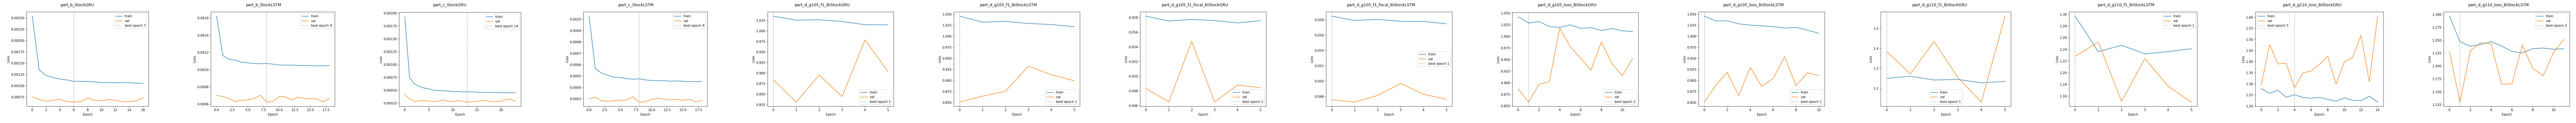

In [18]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plots = sorted(glob.glob('results/hw4/plots/*.png'))
if not plots:
    print('No plots yet.')
else:
    fig, axes = plt.subplots(1, len(plots), figsize=(6 * len(plots), 4))
    if len(plots) == 1:
        axes = [axes]
    for ax, path in zip(axes, plots):
        ax.imshow(mpimg.imread(path))
        ax.set_title(os.path.basename(path).replace('_loss.png', ''), fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## 9. Download Results

All files under the `results/hw4/` will be installed.  
Checkpoints are not included since they are big.

In [19]:
import base64, shutil, os
from IPython.display import display, HTML

tmp_dir = '/tmp/hw4_results'
os.makedirs(tmp_dir, exist_ok=True)
for sub in ('metrics', 'plots'):
    src = f'results/hw4/{sub}'
    if os.path.exists(src):
        shutil.copytree(src, f'{tmp_dir}/{sub}', dirs_exist_ok=True)

zip_path = '/tmp/hw4_results'
shutil.make_archive(zip_path, 'zip', tmp_dir)

with open(zip_path + '.zip', 'rb') as f:
    b64 = base64.b64encode(f.read()).decode()

size_kb = len(b64) * 3 // 4 // 1024
display(HTML(f"""
<a href="data:application/zip;base64,{b64}"
   download="hw4_results.zip"
   style="padding:8px 16px;background:#1a73e8;color:white;
          text-decoration:none;border-radius:4px;font-family:sans-serif;">
    &#11015; Download hw4_results.zip ({size_kb} KB)
</a>
"""))